# LangGraph (Agentic part)

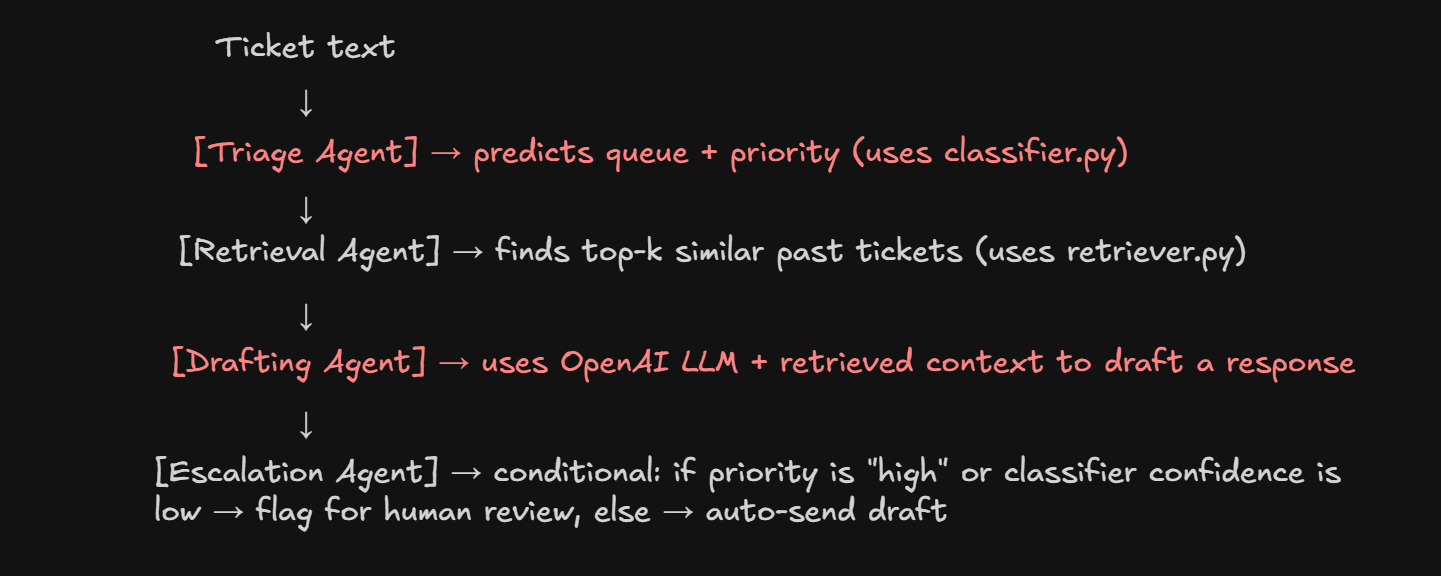
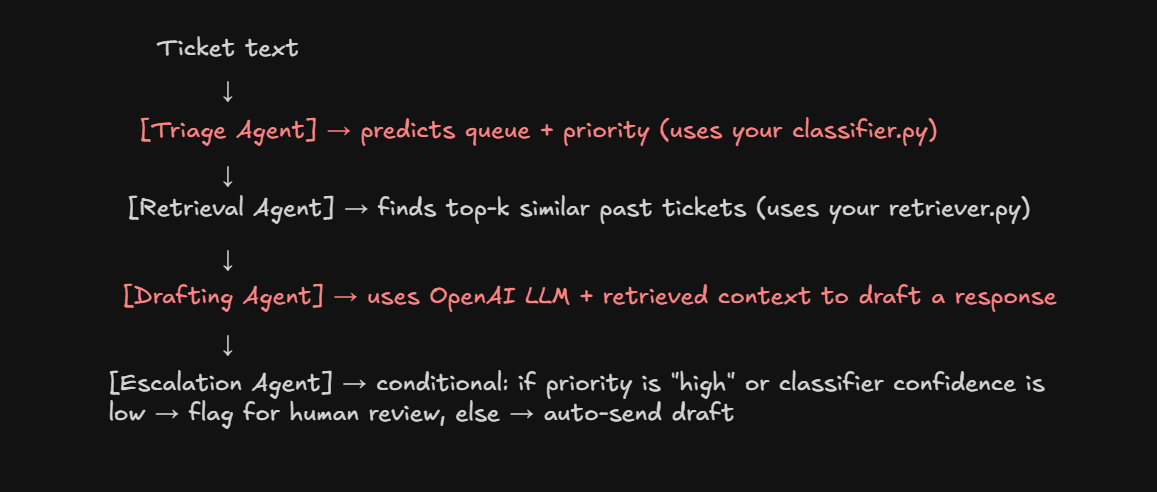

In [8]:
from typing import TypedDict, Optional

class TicketState(TypedDict):
    ticket_text:str
    predicted_queue:Optional[str]
    predicted_priority:Optional[str]
    retrieved_context: Optional[list]
    draft_response: Optional[str]
    escalated: Optional[bool]

 # This TicketState is the object that flows through every node — each agent reads from it and writes back into it.

In [9]:
from triage.rag.knowledge_base import build_knowledge_base
index, df = build_knowledge_base()

In [10]:
from triage.models.classifier import load_artifacts, predict as classify_predict
model, vectorizer, label_encoder = load_artifacts("../models")


In [11]:
def triage_node(state:TicketState)-> TicketState:
    predicted_queue = classify_predict(state['ticket_text'], model ,vectorizer, label_encoder)
    state['predicted_queue'] = predicted_queue
    return state

"""This triage node uses our trained classifier ML model
   classify_predict calls  trained XGBoost model , no OpenAI call happens here.
   The LLM only enters the picture later, in the Drafting Agent node."""

'This triage node uses our trained classifier ML model\n   classify_predict calls  trained XGBoost model , no OpenAI call happens here.\n   The LLM only enters the picture later, in the Drafting Agent node.'

In [12]:
test_state = {"ticket_text": "My internet connection keeps dropping"}
result = triage_node(test_state)
print(result)

# Testing

{'ticket_text': 'My internet connection keeps dropping', 'predicted_queue': 'Technical Support'}


In [ ]:
from triage.rag.retriever import search

def retrieval_node(state:TicketState)->TicketState:
    results = search(state['ticket_text'], index, df, k=3)
    state['retrieved_context'] = results.to_dict('records')
    return state

# this node will retrieve the the emebeddings which we have converted and will be using it 

In [14]:
test_state = {"ticket_text": "My internet connection keeps dropping"}
result = retrieval_node(test_state)
print(result['retrieved_context'])

[{'subject': 'Recurrent Network Connection Interruptions', 'body': 'Below is a succinct issue summary: Problem: Frequent connection drops. Possible cause: Network congestion. Actions Taken: Restarted router with no success. Despite resetting my router, the problem remains unresolved. I would be grateful for any help in resolving this. Kindly inform me if there is any additional data required from you to diagnose the issue.', 'answer': 'We are investigating the recurring connection drops on your network. For a more thorough analysis, could you please share your current internet subscription details and the count of devices connected? This information will aid in providing you with the necessary assistance, or we can schedule a call at a convenient time for a detailed discussion.', 'distance': 0.7637810111045837}, {'subject': 'Frequent Connectivity Drops with Cisco Router', 'body': 'Urgent troubleshooting requested for frequent router drops.', 'answer': "Dear , we're addressing your rout

In [15]:
import os
from openai import OpenAI

llm_client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

def build_draft_prompt(ticket_text: str, retrieved_context: list) -> str:
    context_str = "\n\n".join(
        f"Past ticket: {r['body']}\nResolution given: {r['answer']}"
        for r in retrieved_context
    )
    return f"""You are a customer support agent. A customer submitted this ticket:

"{ticket_text}"

Here are similar past tickets and how they were resolved:

{context_str}

Using this context, draft a helpful, concise response to the customer. Do not mention that you referenced past tickets."""


def drafting_node(state: TicketState) -> TicketState:
    prompt = build_draft_prompt(state['ticket_text'], state['retrieved_context'])
    response = llm_client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.3
    )
    state['draft_response'] = response.choices[0].message.content
    return state

In [16]:
test_state = {"ticket_text": "My internet connection keeps dropping"}
test_state = triage_node(test_state)
test_state = retrieval_node(test_state)
test_state = drafting_node(test_state)
print(test_state['draft_response'])

Subject: Assistance with Your Internet Connection Drops

Dear [Customer's Name],

Thank you for reaching out regarding your internet connection issues. I understand how frustrating it can be when your connection keeps dropping. To help us diagnose the problem more effectively, could you please provide the following information?

1. Your current internet subscription details.
2. The number of devices currently connected to your network.
3. Any specific times when the connection drops occur, or if it happens randomly.

This information will allow us to assist you better. If you prefer, we can also schedule a call to discuss this in more detail. Please let me know your availability.

Looking forward to your response.

Best regards,  
[Your Name]  
Support Team


In [ ]:
# Escalation Node :
def escalation_node(state:TicketState)-> TicketState:
    priority = state.get('predicted_priority')
    queue = state.get('predicted_queue')

    high_risk_queues = {'Billing and Payments', 'Service Outages and Maintenance', 'Human Resources'}

    if queue in high_risk_queues:
        state['escalated'] = True
    else:
        state['escalated'] = False


    return state

    # Note: we're using predicted_queue for the escalation rule since predicted_priority isn't wired in yet (classifier currently predicts queue only — priority prediction would need a second model or classifier head,


In [18]:
test_state['escalated'] = None
result = escalation_node(test_state)
print(result['escalated'])

False


In [29]:
# Building our Graph (LangGraph) :

from langgraph.graph import END, StateGraph

def build_graph():
    graph = StateGraph(TicketState)

    graph.add_node("triage", triage_node)
    graph.add_node("retrieve", retrieval_node)
    graph.add_node("draft", drafting_node)
    graph.add_node("escalate", escalation_node)

    graph.set_entry_point("triage")
    graph.add_edge("retrieve", "draft")
    graph.add_edge("triage", "retrieve")
    graph.add_edge("draft", "escalate")
    graph.add_edge("escalate", END)

    return graph.compile()



In [30]:
app = build_graph()

result = app.invoke({"ticket_text": "My internet connection keeps dropping"})
print(result)

{'ticket_text': 'My internet connection keeps dropping', 'predicted_queue': 'Technical Support', 'retrieved_context': [{'subject': 'Recurrent Network Connection Interruptions', 'body': 'Below is a succinct issue summary: Problem: Frequent connection drops. Possible cause: Network congestion. Actions Taken: Restarted router with no success. Despite resetting my router, the problem remains unresolved. I would be grateful for any help in resolving this. Kindly inform me if there is any additional data required from you to diagnose the issue.', 'answer': 'We are investigating the recurring connection drops on your network. For a more thorough analysis, could you please share your current internet subscription details and the count of devices connected? This information will aid in providing you with the necessary assistance, or we can schedule a call at a convenient time for a detailed discussion.', 'distance': 0.7637810111045837}, {'subject': 'Frequent Connectivity Drops with Cisco Router

In [1]:
from triage.agents.graph import build_graph

app = build_graph(model_dir="../models")
result = app.invoke({"ticket_text": "My internet connection keeps dropping"})
print(result)

{'ticket_text': 'My internet connection keeps dropping', 'predicted_queue': 'Technical Support', 'retrieved_context': [{'subject': 'Recurrent Network Connection Interruptions', 'body': 'Below is a succinct issue summary: Problem: Frequent connection drops. Possible cause: Network congestion. Actions Taken: Restarted router with no success. Despite resetting my router, the problem remains unresolved. I would be grateful for any help in resolving this. Kindly inform me if there is any additional data required from you to diagnose the issue.', 'answer': 'We are investigating the recurring connection drops on your network. For a more thorough analysis, could you please share your current internet subscription details and the count of devices connected? This information will aid in providing you with the necessary assistance, or we can schedule a call at a convenient time for a detailed discussion.', 'distance': 0.7636363506317139}, {'subject': 'Frequent Connectivity Drops with Cisco Router

In [1]:
from triage.agents.drafting_agent import build_draft_prompt
print(build_draft_prompt("test issue", [{"answer": "test resolution"}]))

You are a technical support specialist. Your job is to resolve customer issues directly using only proven prior resolutions.

CUSTOMER ISSUE:
"test issue"

PROVEN RESOLUTIONS FROM SIMILAR PAST TICKETS:
1. test resolution

INSTRUCTIONS:
- Identify which proven resolution(s) above are most relevant to the customer's specific issue.
- Write a direct answer that resolves the issue using that information. Do not invent steps that are not supported by the resolutions above.
- Do not write a greeting, subject line, sign-off, or any email formatting. Output only the resolution content itself.
- Do not ask the customer for more information unless none of the resolutions above provide any usable answer.
- Keep the response under 80 words.
- Address the customer's exact issue — do not include general advice unrelated to their specific problem.

RESPONSE:
